In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pyproj import Proj, Transformer, Geod
import xarray as xr
import earthaccess

MEaSUREs ITS_LIVE Antarctic Grounded Ice Sheet Elevation Change, Version 1:
https://nsidc.org/data/nsidc-0782/versions/1

In [2]:
# 1. Authenticate
auth = earthaccess.login()

In [3]:
# 2. Search for the ITS_LIVE dataset (NSIDC-0782)
granule = earthaccess.search_data(
    short_name="NSIDC-0782",
    version="1"
)

print(f"Found {len(granule)} granule(s) for NSIDC-0782.")
print(f"File name: {granule[0]['meta']['native-id']}")

Found 1 granule(s) for NSIDC-0782.
File name: ANT_G1920_GroundedIceHeight_v01.nc


In [4]:
granule

[Collection: {'EntryTitle': 'MEaSUREs ITS_LIVE Antarctic Grounded Ice Sheet Elevation Change V001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': -54.681, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '1985-04-17T11:10:41.601Z', 'EndingDateTime': '2020-12-16T17:49:16.640Z'}}
 Size(MB): 1840.09
 Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/MEASURES/NSIDC-0782/1/1985/04/17/ANT_G1920_GroundedIceHeight_v01.nc']]

In [5]:
granule[-1]

Collection: {'EntryTitle': 'MEaSUREs ITS_LIVE Antarctic Grounded Ice Sheet Elevation Change V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': -54.681, 'SouthBoundingCoordinate': -90.0}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '1985-04-17T11:10:41.601Z', 'EndingDateTime': '2020-12-16T17:49:16.640Z'}}
Size(MB): 1840.09
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/MEASURES/NSIDC-0782/1/1985/04/17/ANT_G1920_GroundedIceHeight_v01.nc']

In [7]:
# 3. Stream the file handle using earthaccess
file_objs = earthaccess.open(granule)

# 4. Open with xarray
# Note: Unlike ATL15, NSIDC-0782 does not use NetCDF groups,
# so we open it directly without specifying `group=...`
ds = xr.open_dataset(file_objs[0], engine="h5netcdf")

print("\n--- Dataset Summary ---")
print(ds)

# 5. Extract height_change for the last time slice (Dec 2020)
# (height_change is measured in meters relative to 2013-12-16)
dh_latest = ds["height_change"].isel(time=-1)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


--- Dataset Summary ---
<xarray.Dataset> Size: 62GB
Dimensions:             (y: 2916, x: 2916, time: 429)
Coordinates:
  * time                (time) datetime64[ns] 3kB 1985-04-17T11:10:41.6015624...
  * x                   (x) float64 23kB -2.798e+06 -2.796e+06 ... 2.798e+06
  * y                   (y) float64 23kB 2.798e+06 2.796e+06 ... -2.798e+06
Data variables:
    glacier_basin       (y, x) float32 34MB ...
    height              (y, x) float32 34MB ...
    height_change       (time, y, x) float64 29GB ...
    height_change_rmse  (time, y, x) float64 29GB ...
    mapping             float64 8B ...
    quality_flag        (time, y, x) uint8 4GB ...
Attributes:
    Conventions:         CF-1.8
    GDAL_AREA_OR_POINT:  Area
    author:              Johan Nilsson, Alex Gardner, Fernando Paolo - JPL/NASA
    citation:            Nilsson, J., Gardner, A., & Paolo, F. (2021). Elevat...
    date_created:        25-Aug-2022 15:57:08
    doi:                 doi.org/10.5067/L3LSVDZS15ZV
 

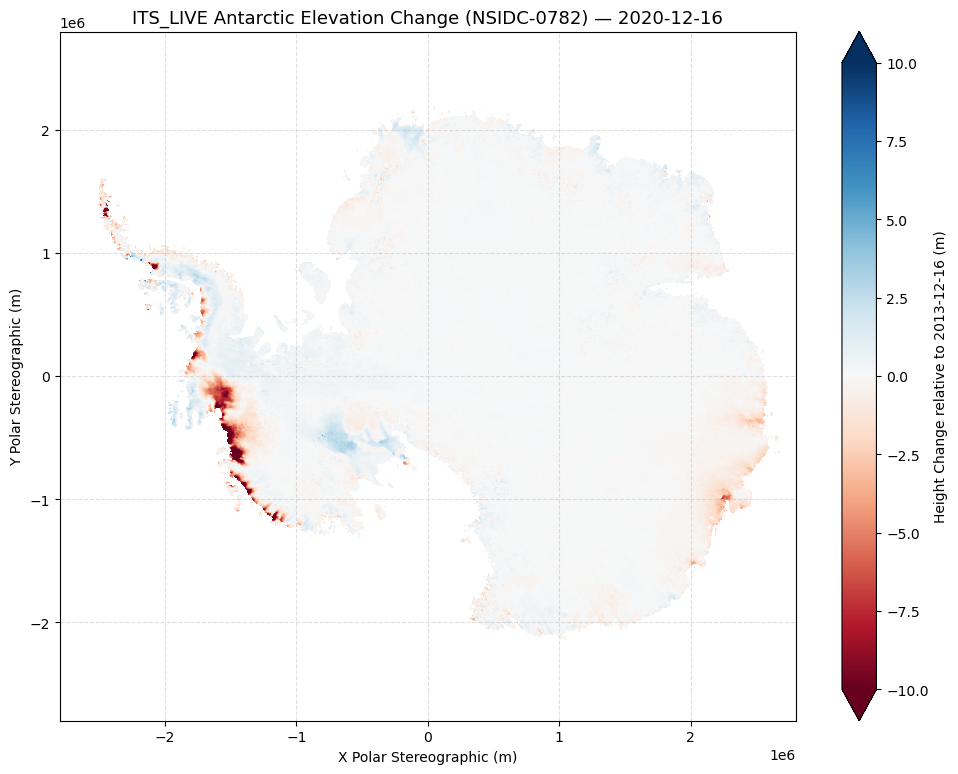

In [8]:
# 6. Plot the elevation change map
fig, ax = plt.subplots(figsize=(10, 8))

dh_latest.plot(
    ax=ax,
    cmap="RdBu",
    vmin=-10,               # Saturation limits in meters
    vmax=10,
    cbar_kwargs={"label": "Height Change relative to 2013-12-16 (m)"}
)

date_str = str(dh_latest.time.values)[:10]
plt.title(f"ITS_LIVE Antarctic Elevation Change (NSIDC-0782) — {date_str}", fontsize=13)
plt.xlabel("X Polar Stereographic (m)")
plt.ylabel("Y Polar Stereographic (m)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()